# Paquetes

In [5]:
import sys
!{sys.executable} -m pip install tqdm

  Using cached tqdm-4.67.3-py3-none-any.whl.metadata (57 kB)
Using cached tqdm-4.67.3-py3-none-any.whl (78 kB)



[notice] A new release of pip is available: 25.3 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [6]:
import numpy as np
import roboticstoolbox as rtb
import matplotlib.pyplot as plt 
from tqdm.auto import tqdm

# Declaracion de robot

In [ ]:
#Nota: con G != 1 la simulacion se cuelga y no se porque
dp = rtb.DHRobot(
    [
        rtb.RevoluteDH(a=0.2,m=1.5,
            r=np.array([-0.1, 0, 0]),
            I=np.array([0,0,0,0,0,0,0,0,1e-3]),
            B=1, G=1),
        rtb.RevoluteDH(a=0.2,m=1,
            r=np.array([-0.1, 0, 0]),
            I=np.array([0,0,0,0,0,0,0,0,1e-4]),
            B=1, G=1)
    ],
    gravity = np.array([0, -9.81, 0]), # Ojo con el signo, la gravedad va hacia abajo con signo positivo
    name="dp")

print(dp)
print(dp.dynamics())

DHRobot: dp, 2 joints (RR), dynamics, standard DH parameters
┌─────┬────┬─────┬──────┐
│ θⱼ  │ dⱼ │ aⱼ  │  ⍺ⱼ  │
├─────┼────┼─────┼──────┤
│  q1 │  0 │ 0.2 │ 0.0° │
│  q2 │  0 │ 0.2 │ 0.0° │
└─────┴────┴─────┴──────┘

┌──┬──┐
└──┴──┘

┌───────┬──────┬──────────────┬─────────────────────────────┬────┬────┬────────┬────┐
│   j   │  m   │      r       │              I              │ Jm │ B  │   Tc   │ G  │
├───────┼──────┼──────────────┼─────────────────────────────┼────┼────┼────────┼────┤
│ link1 │  1.5 │ -0.1,  0,  0 │  0,  0,  0.001,  0,  0,  0  │  0 │  1 │  0,  0 │  1 │
│ link2 │  1   │ -0.1,  0,  0 │  0,  0,  0.0001,  0,  0,  0 │  0 │  1 │  0,  0 │  1 │
└───────┴──────┴──────────────┴─────────────────────────────┴────┴────┴────────┴────┘

None


# Simulacion

In [8]:
solver_kwargs = {
    'rtol': 1e-4     # Tolerancia relativa
    #'atol': 1e-8     # Tolerancia absoluta
    #'max_step': 0.1   # Tamaño máximo del paso de integración
}

## Funciones Utiles

In [9]:
def plot_dinamica(tg, dp):
    # Plot de varaibles articulares
    plt.figure()
    plt.plot(tg.t,tg.q * 180/np.pi)
    plt.xlabel("Tiempo [s]")
    plt.ylabel("q [grados]")
    plt.show()

    plt.figure()
    plt.plot(tg.t,tg.qd * 180/np.pi)
    plt.xlabel("Tiempo [s]")
    plt.ylabel("q [grados]")
    plt.show()

    

    #Plot trayectoria
    plt.figure(figsize=(5,5))
    trayectoria = dp.fkine(tg.q)
    plt.plot(trayectoria.t[:,0],trayectoria.t[:,1],'b-',linewidth=1,label='real')
    plt.legend(loc='upper right')
    plt.xlabel('X [m]')
    plt.ylabel('Y [m]')
    plt.title('Trayectoria realizada')
    plt.axis([-0.4, 0.4, -0.4, 0.4])	
    plt.tight_layout()



## Condicion inicial con rozamiento

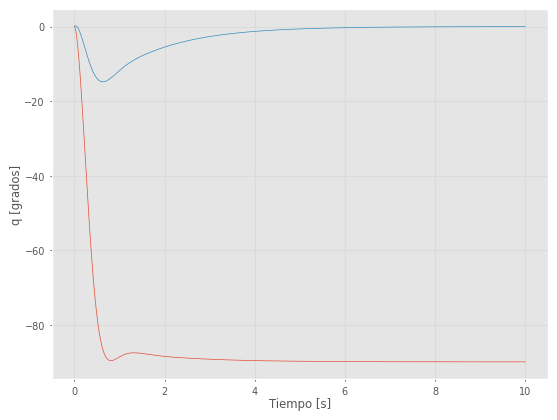

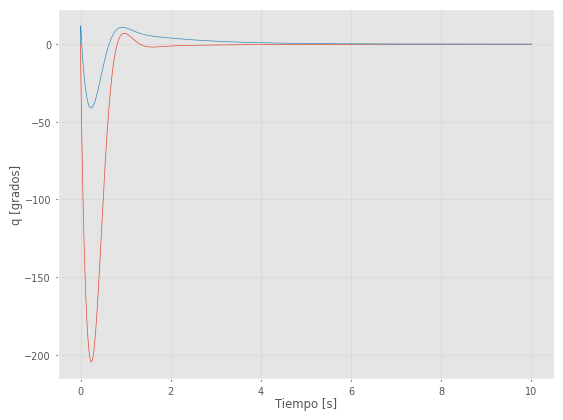

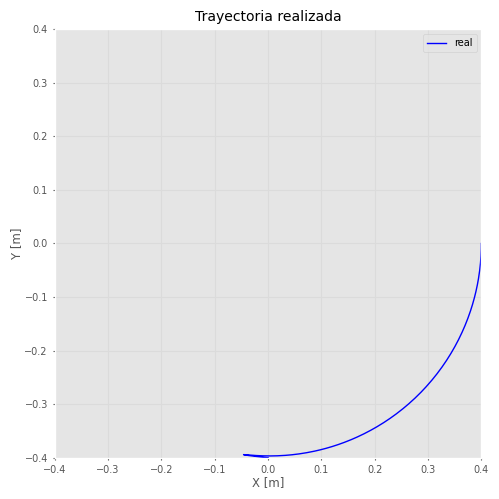

In [10]:
q_ini = np.array([0,0])
qp_ini = np.array([0,0])

tg = dp.nofriction(coulomb=True, viscous=False).fdyn(10, q_ini, qd0 = qp_ini, solver_args= solver_kwargs)

plot_dinamica(tg, dp)


## Poco rozamiento

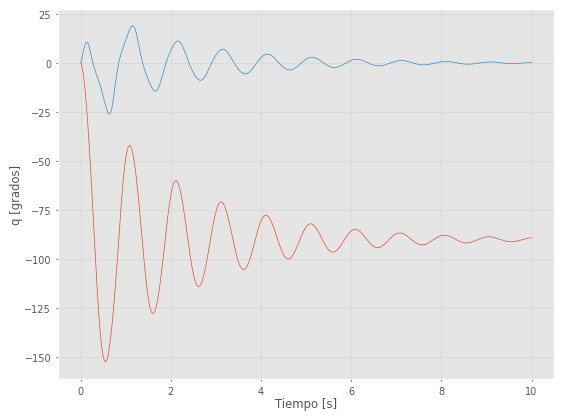

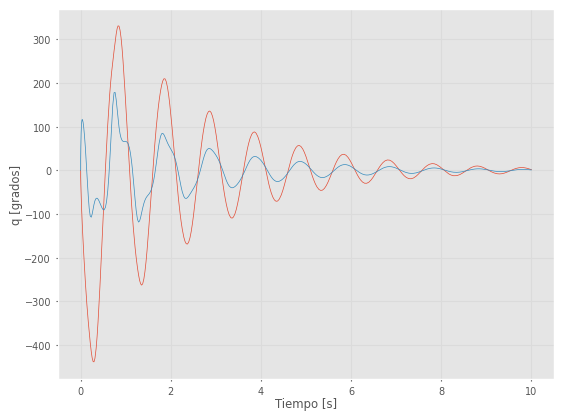

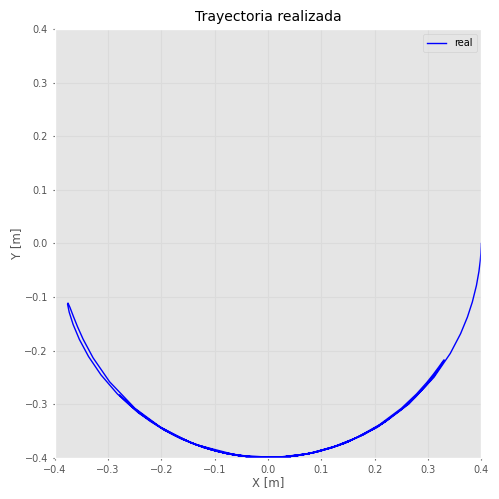

In [11]:
#Modifico la viscosidad del modelo
dp.links[0].B = 0.1
dp.links[1].B = 0.1

q_ini = np.array([0,0])
qp_ini = np.array([0,0])

tg = dp.nofriction(coulomb=True, viscous=False).fdyn(10, q_ini, qd0 = qp_ini, solver_args= solver_kwargs)

plot_dinamica(tg, dp)

## Condicion inicial sin rozamiento (caotico)

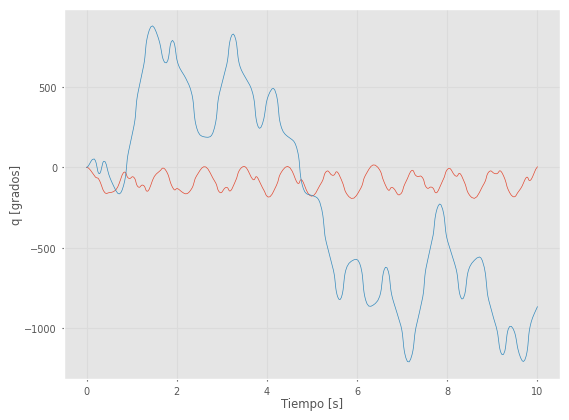

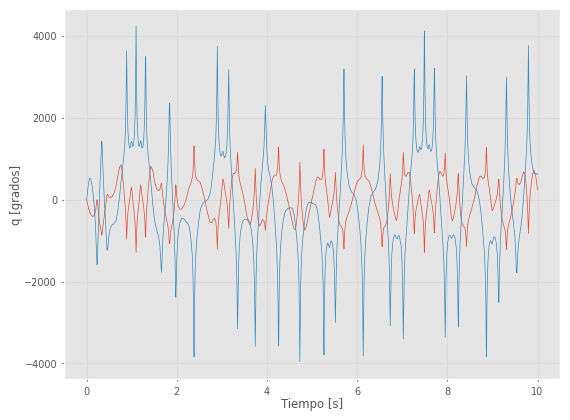

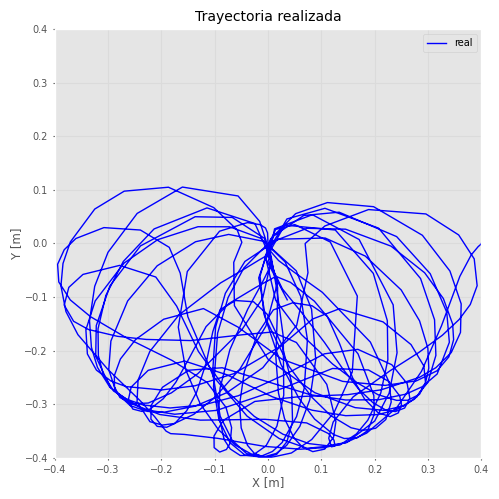

In [12]:
#Modifico la viscosidad del modelo
dp.links[0].B = 0
dp.links[1].B = 0

q_ini = np.array([0,0])
qp_ini = np.array([0,0])

tg = dp.nofriction(coulomb=True, viscous=False).fdyn(10, q_ini, qd0 = qp_ini, solver_args= solver_kwargs)

plot_dinamica(tg, dp)


## Equilibrio Inestable

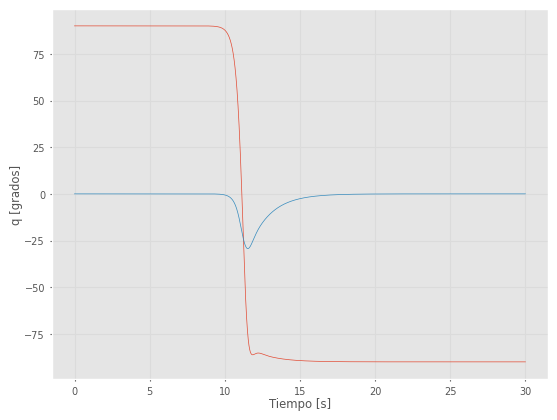

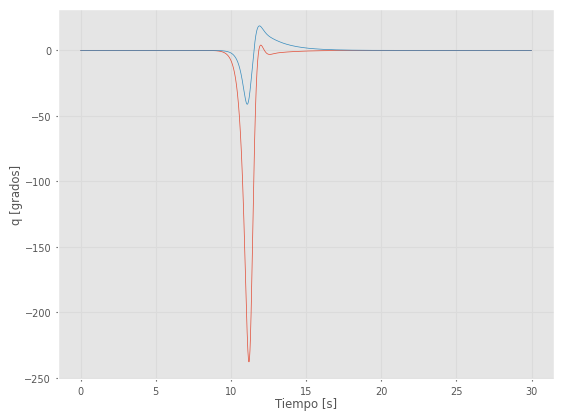

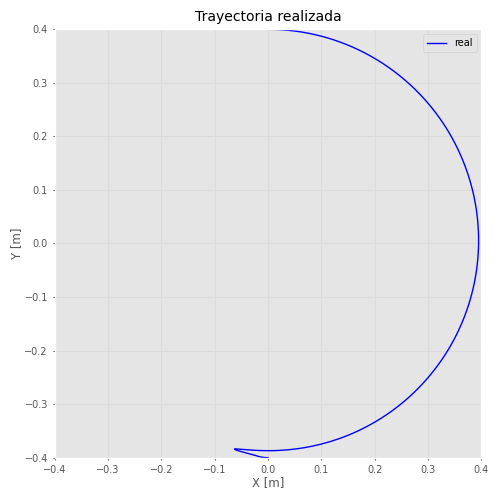

In [13]:
#Modifico la viscosidad del modelo
dp.links[0].B = 1
dp.links[1].B = 1

q_ini = np.array([np.pi/2,0])
qp_ini = np.array([0,0])

tg = dp.nofriction(coulomb=True, viscous=False).fdyn(30, q_ini, qd0 = qp_ini, solver_args= solver_kwargs)

plot_dinamica(tg, dp)
